In [1]:
# Load model directly
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

c:\Users\524ha\anaconda3\envs\seg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
processor = AutoProcessor.from_pretrained("patrickjohncyh/fashion-clip")
model = AutoModelForZeroShotImageClassification.from_pretrained("patrickjohncyh/fashion-clip")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [ ]:
help(processor.__call__)

Help on method __call__ in module transformers.processing_utils:

__call__(images: Union[ForwardRef('PIL.Image.Image'), numpy.ndarray, ForwardRef('torch.Tensor'), list['PIL.Image.Image'], list[numpy.ndarray], list['torch.Tensor'], NoneType] = None, text: Union[str, list[str], list[list[str]], NoneType] = None, videos: Union[list['PIL.Image.Image'], numpy.ndarray, ForwardRef('torch.Tensor'), list[numpy.ndarray], list['torch.Tensor'], list[list['PIL.Image.Image']], list[list[numpy.ndarray]], list[list['torch.Tensor']], transformers.video_utils.URL, list[transformers.video_utils.URL], list[list[transformers.video_utils.URL]], transformers.video_utils.Path, list[transformers.video_utils.Path], list[list[transformers.video_utils.Path]], NoneType] = None, audio: Union[numpy.ndarray, ForwardRef('torch.Tensor'), collections.abc.Sequence[numpy.ndarray], collections.abc.Sequence['torch.Tensor'], NoneType] = None, **kwargs: Unpack[transformers.processing_utils.ProcessingKwargs]) method of transfo

In [13]:
shirt_labels = [
    "a photo of a white shirt",
    "a photo of a black shirt",
    "a photo of a gray shirt",
    "a photo of a red shirt",
    "a photo of a dark red shirt",
    "a photo of a blue shirt",
    "a photo of a light blue shirt",
    "a photo of a navy blue shirt",
    "a photo of a green shirt",
    "a photo of a dark green shirt",
    "a photo of a yellow shirt",
    "a photo of an orange shirt",
    "a photo of a brown shirt",
    "a photo of a beige shirt",
    "a photo of a pink shirt",
    "a photo of a purple shirt",
    "a photo of a dark purple shirt",
    "a photo of a light gray shirt",
    "a photo of a turquoise shirt",
    "a photo of a cyan shirt",
    "a photo of a magenta shirt",
    "a photo of a gold shirt",
    "a photo of a silver shirt",
    "a photo of a maroon shirt",
    "a photo of an olive shirt",
    "a photo of a teal shirt",
    "a photo of a sky blue shirt",
    "a photo of a dark brown shirt",
    "a photo of a violet shirt",
    "a photo of a cream shirt"
]

shirt_labels_short = [
    "a photo of a white shirt",
    "a photo of a black shirt"]

player_or_referee_labels = [
    "a photo of a wearing pants",
    "a photo of a wearing shirts"
]

image_list = []
for i in range(1, 8):
    img_path = f"../dark{i}.jpg"
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_list.append(image)
#plt.imshow(image)
#image_now = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#plt.imshow(image_now)

referee = cv2.imread("../referee.jpg")
referee = cv2.cvtColor(referee, cv2.COLOR_BGR2RGB)

inputs = processor(text=player_or_referee_labels, images=referee, return_tensors="pt", padding=True)

In [14]:
scores = model(**inputs)

scores.logits_per_image[0]


tensor([32.3096, 28.3835], grad_fn=<SelectBackward0>)

tensor([[0.9807, 0.0193]], grad_fn=<SoftmaxBackward0>)


<BarContainer object of 2 artists>

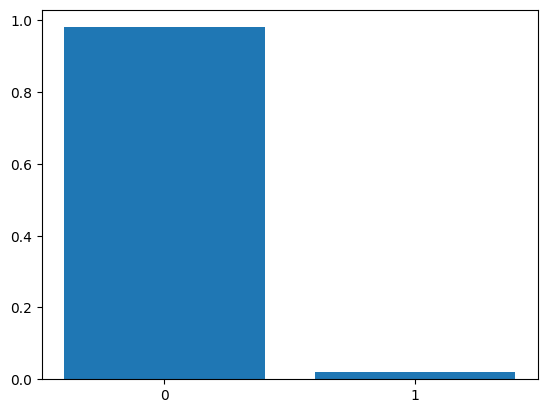

In [15]:
lpi = scores.logits_per_image[0]
probs = lpi.unsqueeze(0).softmax(dim=1)
print(probs)

plt.bar([str(a) for a in np.arange(0, 2, 1)], probs.detach().numpy()[0])

In [87]:
torch.max(scores.logits_per_image.softmax(dim=1), dim=1)

torch.return_types.max(
values=tensor([0.9993, 0.9991, 0.9995, 0.9979, 0.9966, 0.9999, 0.9800],
       grad_fn=<MaxBackward0>),
indices=tensor([1, 1, 1, 1, 1, 1, 0]))

In [ ]:

results = model.predict(source="../referee.jpg", conf=0.25, save=True)


image 1/1 c:\Users\524ha\Desktop\Resources\BasketballGameTracker\playerdetection\..\referee.jpg: 640x320 1 Player, 100.8ms
Speed: 5.2ms preprocess, 100.8ms inference, 197.6ms postprocess per image at shape (1, 3, 640, 320)
Results saved to C:\Users\524ha\Desktop\Resources\BasketballGameTracker\playerdetection\runs\detect\predict


In [23]:
import time
import cv2

from ultralytics import YOLO

model = YOLO("../models/yolo/player_detector.pt")

# Open the video file
video_path = "../videos/input/court2.mp4"
cap = cv2.VideoCapture(video_path)

# Loop through the video frames
while cap.isOpened():
    # Read a frame from the video
    success, frame = cap.read()
    time.sleep(0.03)  # Adjust sleep time as needed for display speed
    if success:
        # Run YOLO inference on the frame
        results = model(frame)

        # Visualize the results on the frame
        annotated_frame = results[0].plot()

        # Display the annotated frame
        cv2.imshow("YOLO Inference", annotated_frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        # Break the loop if the end of the video is reached
        break

# Release the video capture object and close the display window
cap.release()
cv2.destroyAllWindows()


0: 384x640 (no detections), 22.4ms
Speed: 1.3ms preprocess, 22.4ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 20.8ms
Speed: 1.1ms preprocess, 20.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 18.0ms
Speed: 1.2ms preprocess, 18.0ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 17.6ms
Speed: 1.2ms preprocess, 17.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Players, 19.1ms
Speed: 1.4ms preprocess, 19.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Players, 18.1ms
Speed: 1.4ms preprocess, 18.1ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Player, 18.0ms
Speed: 1.3ms preprocess, 18.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Player, 20.0ms
Speed: 1.2ms preprocess, 20.0ms inference, 1.3ms postproces

In [12]:
import cv2
import numpy as np
import os
import glob
import shutil
from tqdm import tqdm

def convert_mask_to_yolo(mask_path, image_shape):
    """
    Bir maske (.png) dosyasını okur ve YOLO segmentasyon .txt formatına çevirir.
    Her bir instance'ı (oyuncu) farklı bir piksel değeriyle (1, 2, 3, ...) kodlar.
    """
    
    img_h, img_w = image_shape
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return ""

    instance_ids = np.unique(mask)
    instance_ids = instance_ids[instance_ids != 0] # Arka planı (0) çıkar

    yolo_lines = []
    
    for instance_id in instance_ids:
        instance_mask = (mask == instance_id).astype(np.uint8)
        
        contours, _ = cv2.findContours(instance_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Sadece "human" sınıfı olduğu için class_id hep 0 olacak
        class_id = 0
        
        for contour in contours:
            if contour.shape[0] < 3: # Geçerli bir poligon için en az 3 nokta gerekir
                continue

            # (N, 1, 2) -> (N, 2)
            normalized_contour = contour.astype(np.float32).squeeze(1)
            
            # Koordinatları normalize et (0-1 aralığı)
            normalized_contour[:, 0] /= img_w  # X koordinatları
            normalized_contour[:, 1] /= img_h  # Y koordinatları
            
            # (x1, y1, x2, y2, ...) şeklinde düz bir string'e çevir
            points_str = " ".join(normalized_contour.flatten().astype(str))
            
            yolo_line = f"{class_id} {points_str}"
            yolo_lines.append(yolo_line)

    return "\n".join(yolo_lines)

# --- ANA SCRIPT ---

# 1. Klasör Yollarını Tanımla
ROOT_DIR = '../data/seg/bid' # Bu script'in çalıştığı yer (KS-FR-... klasörlerinin olduğu yer)
OUTPUT_DIR = '../data/seg/basketball_players_and_ball'
OUTPUT_IMAGES_DIR = os.path.join(OUTPUT_DIR, 'images')
OUTPUT_LABELS_DIR = os.path.join(OUTPUT_DIR, 'labels')

# 2. Çıktı Klasörlerini Oluştur
os.makedirs(OUTPUT_IMAGES_DIR, exist_ok=True)
os.makedirs(OUTPUT_LABELS_DIR, exist_ok=True)

print(f"Çıktı klasörleri hazırlanıyor: ./{OUTPUT_DIR}/")

print(ROOT_DIR)
# 3. Tüm kaynak görüntüleri bul (sadece KS-FR- ile başlayan klasörlerin içinde)
image_paths = glob.glob(os.path.join(ROOT_DIR, 'KS-FR-*', '*', '*_0.png'))

      
if not image_paths:
    print(f"Hata: '{ROOT_DIR}' içinde 'KS-FR-' ile başlayan klasörlerde hiç '*_0.png' dosyası bulunamadı.")
    print("Lütfen script'i doğru dizinde çalıştırdığınızdan emin olun.")
else:
    print(f"Toplam {len(image_paths)} adet kaynak resim bulundu. İşlem başlıyor...")
    processed_count = 0
    # 4. Her bir görüntüyü işle
    for img_path in tqdm(image_paths, desc="Veriseti hazırlanıyor"):
        
        # 4a. İlgili maske dosyasının yolunu bul
        mask_path = img_path.replace('_0.png', '_humans.png')
        if not os.path.exists(mask_path):
            tqdm.write(f"Uyarı: {mask_path} bulunamadı, {img_path} atlanıyor.")
            continue

        # 4b. Orijinal görüntüyü oku (boyutları almak için)
        img = cv2.imread(img_path)
        if img is None:
            tqdm.write(f"Uyarı: {img_path} okunamadı/bozuk, atlanıyor.")
            continue
        img_shape = img.shape[:2] # (height, width)

        # 4c. Maskeyi YOLO .txt formatına dönüştür
        yolo_data = convert_mask_to_yolo(mask_path, img_shape)
        
        # 4d. Yeni dosya isimlerini belirle
        # Dosya adını 'KS-FR-BLOIS/camcourt1..._0.png' değil,
        # sadece 'camcourt1..._0.png' olarak alır.
        base_filename = os.path.basename(img_path)
        label_filename = base_filename.replace('.png', '.txt')
        
        # 4e. Yeni çıktı yollarını belirle
        new_img_path = os.path.join(OUTPUT_IMAGES_DIR, base_filename)
        new_label_path = os.path.join(OUTPUT_LABELS_DIR, label_filename)

        # 4f. YOLO .txt etiket dosyasını yaz
        # (Eğer maskede hiç insan bulunmazsa boş bir .txt dosyası oluşturur,
        # bu YOLO'nun "negatif" örnekleri öğrenmesi için doğrudur)
        with open(new_label_path, 'w') as f:
            f.write(yolo_data)
            
        # 4g. Orijinal görüntü dosyasını kopyala
        shutil.copy2(img_path, new_img_path)
        processed_count += 1

    print(f"\nİşlem tamamlandı!")
    print(f"Toplam {processed_count} resim/etiket çifti işlendi.")
    print(f"Resimler şuraya kaydedildi: ./{OUTPUT_IMAGES_DIR}")
    print(f"Etiketler şuraya kaydedildi: ./{OUTPUT_LABELS_DIR}")

Çıktı klasörleri hazırlanıyor: ./../data/seg/basketball_players_and_ball/
../data/seg/bid
Toplam 310 adet kaynak resim bulundu. İşlem başlıyor...


Veriseti hazırlanıyor: 100%|██████████| 310/310 [00:39<00:00,  7.91it/s]


İşlem tamamlandı!
Toplam 310 resim/etiket çifti işlendi.
Resimler şuraya kaydedildi: ./../data/seg/basketball_players_and_ball\images
Etiketler şuraya kaydedildi: ./../data/seg/basketball_players_and_ball\labels
